# 数据可视化汇总

本笔记本整合了所有可视化内容，用于论文图表生成：
1. 建筑负荷数据可视化
2. 特征相关性分析
3. 迁移学习结果可视化

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 从 src 模块导入共享配置
from src import (
    BASE_DIR,
    BUILDINGS_DIR,
    BUILDINGS,
    SOURCE_BUILDING,
    TARGET_BUILDING,
    FIGURES_DIR,
    TARGET_COL,
    TIME_COL,
    setup_plot_style,
)

setup_plot_style()

## 一、负荷数据可视化

In [ ]:
# 加载所有建筑的预处理后负荷数据
load_data_dict = {}
for name in BUILDINGS:
    path = BUILDINGS_DIR / f'{name}_预处理后.csv'
    if path.exists():
        df = pd.read_csv(path, parse_dates=[TIME_COL])
        df.set_index(TIME_COL, inplace=True)
        load_data_dict[name] = df

# 绘制所有建筑的小时负荷对比
fig, axes = plt.subplots(len(load_data_dict), 1, figsize=(14, 4*len(load_data_dict)), sharex=True)

if len(load_data_dict) == 1:
    axes = [axes]

colors = ['coral', 'seagreen', 'steelblue', 'purple', 'orange']

for i, (name, df) in enumerate(load_data_dict.items()):
    ax = axes[i]
    ax.plot(df.index, df[TARGET_COL], color=colors[i % len(colors)], 
            linewidth=0.8, alpha=0.8)
    ax.set_ylabel('小时电量 (kWh)')
    ax.set_title(f'{name} 小时负荷曲线')
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '所有建筑小时负荷曲线.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 源域与目标域负荷对比
if SOURCE_BUILDING in load_data_dict and TARGET_BUILDING in load_data_dict:
    fig, ax = plt.subplots(figsize=(14, 5))
    
    source_df = load_data_dict[SOURCE_BUILDING]
    target_df = load_data_dict[TARGET_BUILDING]
    
    ax.plot(source_df.index, source_df[TARGET_COL], 'b-', 
            linewidth=0.8, alpha=0.7, label="源域")
    ax.plot(target_df.index, target_df[TARGET_COL], 'r-', 
            linewidth=0.8, alpha=0.7, label="目标域")
    
    ax.set_xlabel('时间')
    ax.set_ylabel('小时电量 (kWh)')
    ax.set_title(f'源域({SOURCE_BUILDING})与目标域({TARGET_BUILDING})负荷对比')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# 按月展示负荷曲线
for name, df in load_data_dict.items():
    df_monthly = df.copy()
    df_monthly['month'] = df_monthly.index.month
    months = sorted(df_monthly['month'].unique())
    n_months = len(months)
    
    fig, axes = plt.subplots(n_months, 1, figsize=(14, 2.5*n_months), sharex=False)
    if n_months == 1:
        axes = [axes]
    
    for i, month in enumerate(months):
        month_data = df_monthly[df_monthly['month'] == month]
        axes[i].plot(month_data.index, month_data[TARGET_COL], 
                     color='coral', linewidth=0.8, alpha=0.8)
        axes[i].set_title(f'{name} - {month}月小时负荷')
        axes[i].set_ylabel('kWh')
        axes[i].grid(True, alpha=0.3)
        
        axes[i].xaxis.set_major_locator(mdates.DayLocator(interval=5))
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{name}_月度负荷曲线.png', dpi=150, bbox_inches='tight')
    plt.show()

## 二、特征相关性分析

In [ ]:
# 加载特征数据
feature_data_dict = {}
for name in BUILDINGS:
    path = BUILDINGS_DIR / f'{name}_特征.csv'
    if path.exists():
        df = pd.read_csv(path, parse_dates=[TIME_COL])
        df.set_index(TIME_COL, inplace=True)
        feature_data_dict[name] = df
        print(f"{name}: {df.shape}")

# 特征相关性分析
for name, df in feature_data_dict.items():
    # 获取所有数值列
    all_features = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_cols = ['month', 'hour', 'temp_bin']
    all_features = [col for col in all_features if col not in exclude_cols]
    
    if TARGET_COL not in all_features:
        continue
    
    # 计算与目标负荷列的相关系数
    target_corr = df[all_features].corr()[TARGET_COL].drop(TARGET_COL)
    target_corr = target_corr.sort_values(key=abs, ascending=False).head(10)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 根据正负相关性着色
    colors = ['coral' if x > 0 else 'steelblue' for x in target_corr.values]
    bars = ax.barh(range(len(target_corr)), target_corr.values, 
                   color=colors, alpha=0.7, edgecolor='white')
    
    ax.set_yticks(range(len(target_corr)))
    ax.set_yticklabels(target_corr.index)
    ax.set_xlabel('相关系数')
    ax.set_title(f'{name} - 与小时负荷最相关的10个特征')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')
    
    # 添加数值标签
    for i, (bar, val) in enumerate(zip(bars, target_corr.values)):
        ax.text(val + 0.01 if val > 0 else val - 0.01, i, f'{val:.3f}', 
                va='center', ha='left' if val > 0 else 'right', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{name}_特征相关性.png', dpi=150, bbox_inches='tight')
    plt.show()

## 三、迁移学习结果可视化

      策略      MAE      RMSE     MAPE       R2
Baseline 9.109162 12.946689 7.201392 0.898193
   全参数微调 7.159620 11.017163 5.785107 0.926277
冻结LSTM微调 7.744045 12.324503 6.262751 0.907743
    特征提取 7.090121 11.235187 5.626662 0.923331


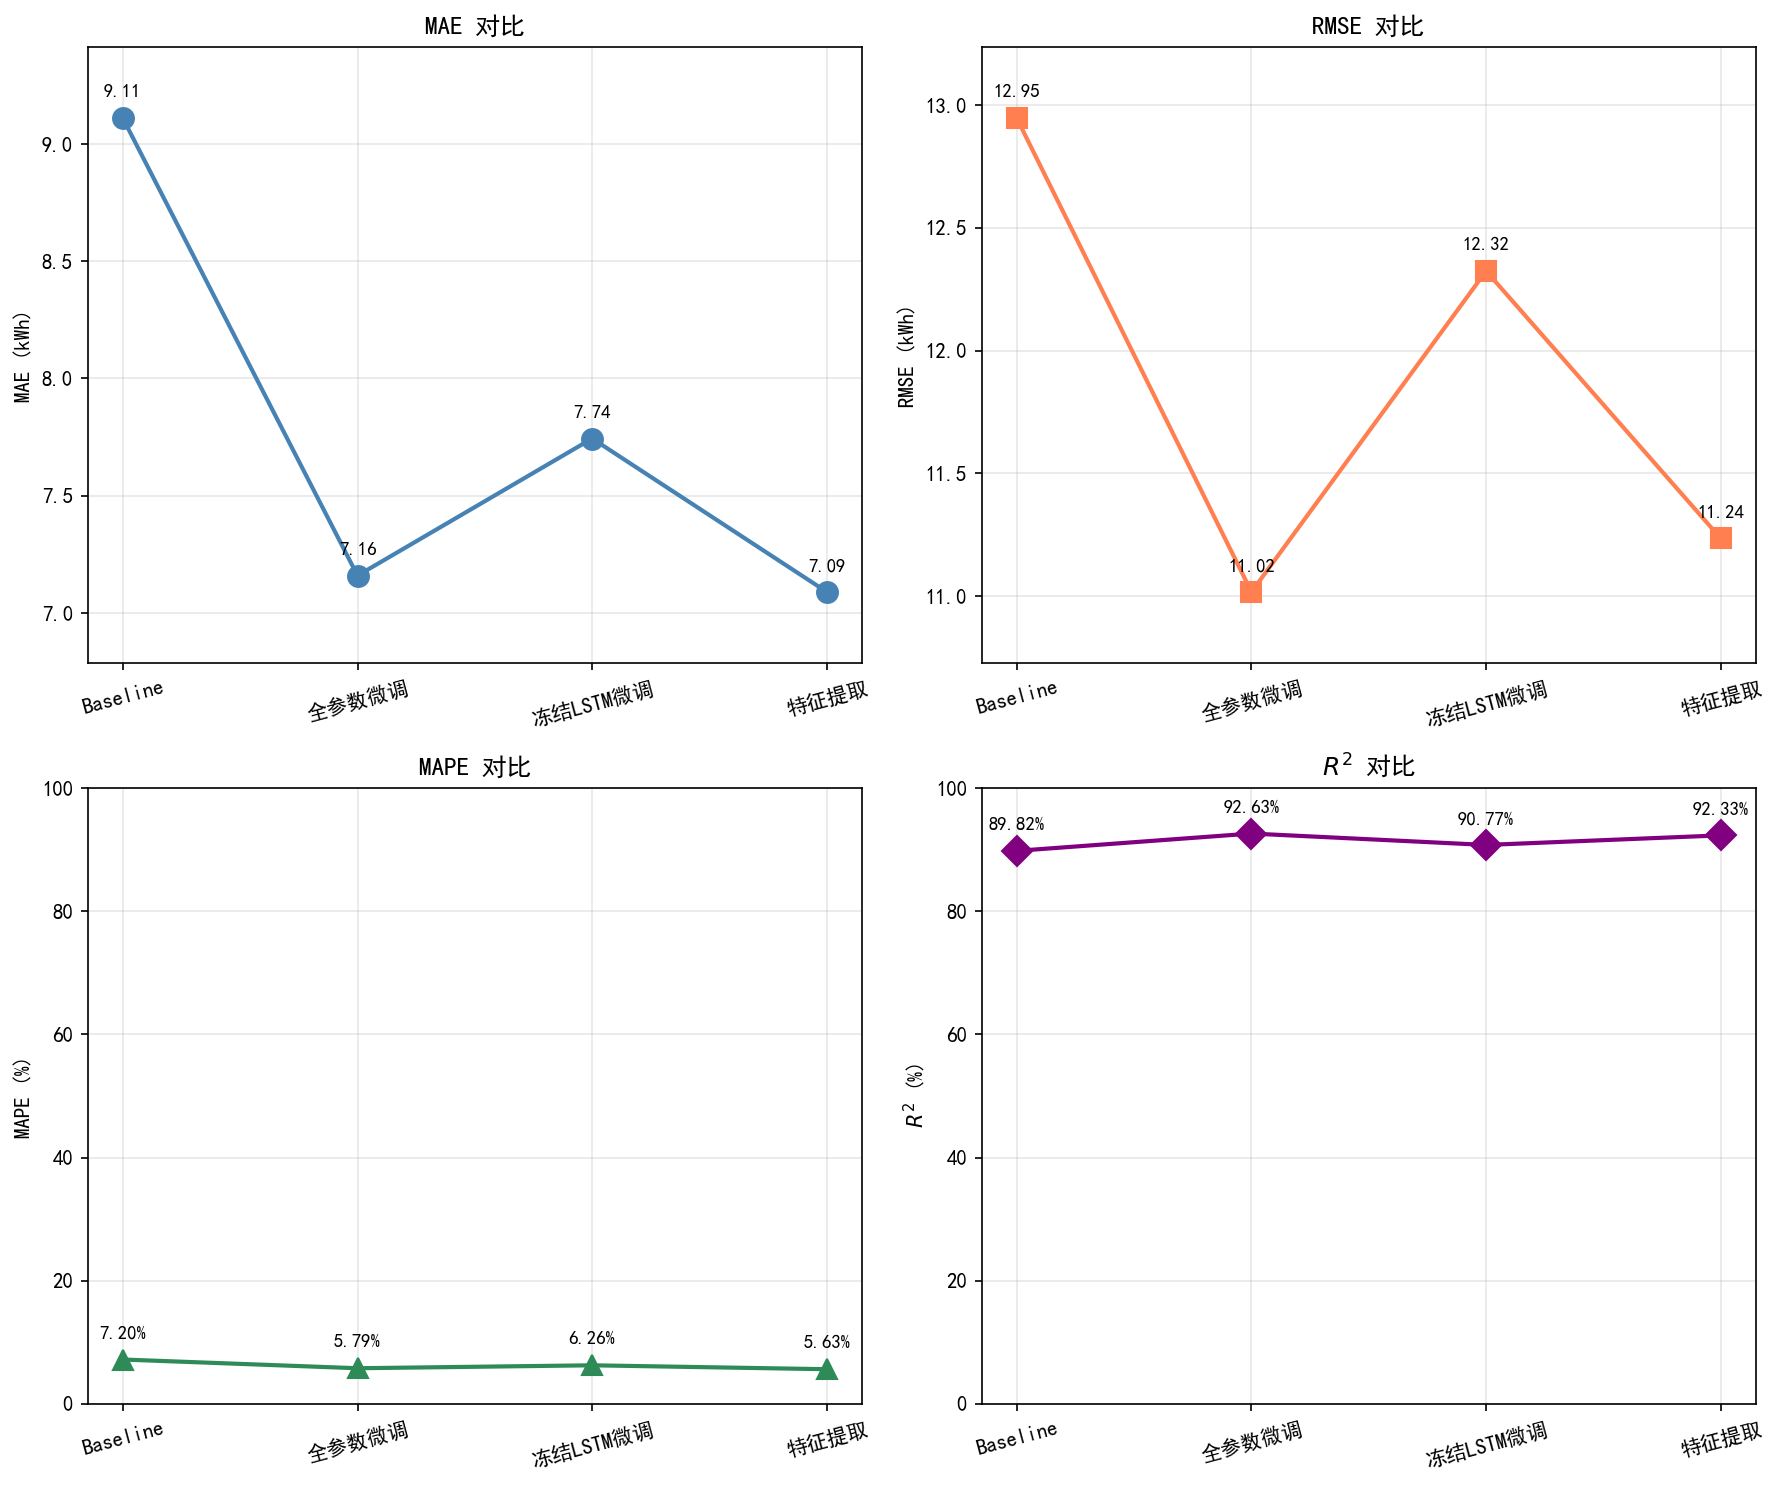

In [6]:
# 加载迁移学习结果
results_path = BASE_DIR / 'transfer_learning_results.csv'

if results_path.exists():
    results_df = pd.read_csv(results_path)
    print(results_df.to_string(index=False))
    
    # 性能对比折线图
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
    colors = ['steelblue', 'coral', 'seagreen', 'purple']
    markers = ['o', 's', '^', 'D']
    
    strategies = results_df['策略'].tolist()
    x = range(len(strategies))
    
    # MAE 对比（根据数据范围设置纵轴）
    ax = axes[0, 0]
    values = results_df['MAE'].values
    ax.plot(x, values, color=colors[0], marker=markers[0], 
            linewidth=2, markersize=10, label='MAE')
    for j, val in enumerate(values):
        ax.annotate(f'{val:.2f}', (j, val), 
                   textcoords="offset points", xytext=(0, 10),
                   ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, rotation=15)
    ax.set_ylabel('MAE (kWh)')
    ax.set_title('MAE 对比')
    # 纵轴范围：数据范围上下留 15% 空白
    mae_min, mae_max = values.min(), values.max()
    mae_range = mae_max - mae_min
    ax.set_ylim(mae_min - 0.15 * mae_range, mae_max + 0.15 * mae_range)
    ax.grid(True, alpha=0.3)
    
    # RMSE 对比（根据数据范围设置纵轴）
    ax = axes[0, 1]
    values = results_df['RMSE'].values
    ax.plot(x, values, color=colors[1], marker=markers[1], 
            linewidth=2, markersize=10, label='RMSE')
    for j, val in enumerate(values):
        ax.annotate(f'{val:.2f}', (j, val), 
                   textcoords="offset points", xytext=(0, 10),
                   ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, rotation=15)
    ax.set_ylabel('RMSE (kWh)')
    ax.set_title('RMSE 对比')
    # 纵轴范围：数据范围上下留 15% 空白
    rmse_min, rmse_max = values.min(), values.max()
    rmse_range = rmse_max - rmse_min
    ax.set_ylim(rmse_min - 0.15 * rmse_range, rmse_max + 0.15 * rmse_range)
    ax.grid(True, alpha=0.3)
    
    # MAPE 对比（纵轴 0-100%）
    ax = axes[1, 0]
    values = results_df['MAPE'].values
    ax.plot(x, values, color=colors[2], marker=markers[2], 
            linewidth=2, markersize=10, label='MAPE')
    for j, val in enumerate(values):
        ax.annotate(f'{val:.2f}%', (j, val), 
                   textcoords="offset points", xytext=(0, 10),
                   ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, rotation=15)
    ax.set_ylabel('MAPE (%)')
    ax.set_title('MAPE 对比')
    ax.set_ylim(0, 100)  # 纵轴 0-100%
    ax.grid(True, alpha=0.3)
    
    # R² 对比（纵轴 0-100%，将 0-1 转换为 0-100%）
    ax = axes[1, 1]
    values = results_df['R2'].values * 100  # 转换为百分比
    ax.plot(x, values, color=colors[3], marker=markers[3], 
            linewidth=2, markersize=10, label='$R^2$')
    for j, val in enumerate(values):
        ax.annotate(f'{val:.2f}%', (j, val), 
                   textcoords="offset points", xytext=(0, 10),
                   ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, rotation=15)
    ax.set_ylabel('$R^2$ (%)')
    ax.set_title('$R^2$ 对比')
    ax.set_ylim(0, 100)  # 纵轴 0-100%
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '迁移学习性能对比.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"未找到迁移学习结果文件: {results_path}")
    print("请先运行 transfer_learning.ipynb")

## 四、输出文件说明

所有图表保存在 `data/figures/` 目录：

| 文件 | 说明 |
|------|------|
| `所有建筑小时负荷曲线.png` | 所有建筑的小时负荷对比 |
| `{建筑名}_月度负荷曲线.png` | 各建筑的月度负荷曲线 |
| `{建筑名}_特征相关性.png` | 各建筑的特征相关性分析 |
| `迁移学习性能对比.png` | 迁移学习策略性能对比（折线图） |
